In [49]:
# Reproducibility
import warnings
warnings.filterwarnings("ignore")

# Hyperliquid Trader Behavior vs Market Sentiment Analysis

# Hyperliquid Trader Behavior vs Market Sentiment Analysis

The goal is to study whether Bitcoin market sentiment (Fear/Greed) is associated with differences in trader behavior and performance on Hyperliquid.
I test this by merging daily sentiment labels with trade-level Hyperliquid data, then comparing PnL, win rate, trade frequency, position size, and directional bias across sentiment regimes.


I load the two CSV files into separate DataFrames because they come from different sources and must first be cleaned independently before merging.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

Initial inspection

In [18]:
print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)

print("\nTrades columns:")
print(trades.columns.tolist())

print("\nSentiment columns:")
print(sentiment.columns.tolist())

display(trades.head())
display(sentiment.head())

Trades shape: (211224, 16)
Sentiment shape: (2644, 4)

Trades columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Sentiment columns:
['timestamp', 'value', 'classification', 'date']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


historical_data.csv has 211,224 rows

fear_greed_index.csv has 2,644 rows

Data quality checks

Missing values can break aggregations, distort averages, or create merge failures.
Duplicate rows can double-count trades or sentiment observations, so they must be checked before analysis.

In [19]:
print("Missing values in trades:")
print(trades.isna().sum())

print("\nMissing values in sentiment:")
print(sentiment.isna().sum())

print("\nDuplicate rows in trades:", trades.duplicated().sum())
print("Duplicate rows in sentiment:", sentiment.duplicated().sum())

Missing values in trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows in trades: 0
Duplicate rows in sentiment: 0


I checked full-row duplication first. Since full duplicate rows were zero, I did not blindly deduplicate by Trade ID, because repeated IDs may represent valid multi-fill or event-level records. Removing them without domain confirmation could incorrectly discard real trading activity.

Timestamp cleaning

file has both:

Timestamp IST

Timestamp

The safest one for daily analysis is Timestamp IST, because it is already human-readable and aligned to India time.

In [20]:
trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], dayfirst=True, errors="coerce")
trades["date"] = trades["Timestamp IST"].dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce").dt.date

The analysis is done at daily level, so both datasets need a common daily key.
I converted the trader timestamp to datetime, then extracted only the date component.
I did the same for the sentiment file so both datasets can be merged on calendar date.

why dayfirst=True is used:

Timestamp IST is in day-month-year format, so dayfirst=True is required to parse dates correctly.

Merge the datasets

In [21]:
data = trades.merge(
    sentiment[["date", "classification", "value"]],
    on="date",
    how="left"
)

I performed a left join from trades to sentiment so that every trade remains in the dataset, even if a sentiment label is missing for a small number of dates.
This is appropriate because the trades dataset is the main unit of analysis, and sentiment is an explanatory variable added to each trade date.

checking the merge quality:

In [22]:
print("Missing sentiment after merge:", data["classification"].isna().sum())
print(data.loc[data["classification"].isna(), ["date"]].drop_duplicates())

Missing sentiment after merge: 6
           date
727  2024-10-26


The merge left only a very small number of unmatched rows. Since the unmatched count is negligible relative to total trades, I excluded those rows from sentiment-based comparisons.

In [23]:
data = data.dropna(subset=["classification"]).copy()

Feature engineering

In [24]:
data["is_win"] = data["Closed PnL"] > 0
data["is_loss"] = data["Closed PnL"] < 0
data["is_closed_trade"] = data["Closed PnL"] != 0

Closed PnL is the most direct realized performance measure available in the dataset.
A positive value indicates a profitable realized outcome, a negative value indicates a losing realized outcome, and zero often corresponds to non-closing events or trades with no realized PnL at that row level.

Directional features

Side captures execution direction at order level, while Direction contains richer position context such as Open Long, Close Long, Open Short, and Close Short.
I derive long/short indicators from Direction to approximate directional bias.

In [25]:
data["abs_size_usd"] = data["Size USD"].abs()
data["net_trade_value"] = data["Size USD"]

The assignment asks for leverage analysis, but leverage is not available in the provided data.
Therefore, I use Size USD as a risk-exposure proxy: larger notional size generally implies larger capital at risk per trade.

Build analysis tables

I should analyze at two levels:

Trade-level

Trader-day level

Trade-level alone can be noisy. Trader-day level is more strategic.

Trade-level sentiment summary

In [26]:
closed_trades = data[data["is_closed_trade"]].copy()

trade_sentiment_summary = closed_trades.groupby("classification").agg(
    closed_trade_count=("Closed PnL", "size"),
    total_pnl=("Closed PnL", "sum"),
    avg_pnl_per_closed_trade=("Closed PnL", "mean"),
    median_pnl_per_closed_trade=("Closed PnL", "median"),
    win_rate=("is_win", "mean"),
    avg_trade_size_usd=("abs_size_usd", "mean"),
    median_trade_size_usd=("abs_size_usd", "median"),
    avg_fee=("Fee", "mean")
).sort_values("avg_pnl_per_closed_trade", ascending=False)

trade_sentiment_summary

,closed_trade_count,total_pnl,avg_pnl_per_closed_trade,median_pnl_per_closed_trade,win_rate,avg_trade_size_usd,median_trade_size_usd,avg_fee
classification,,,,,,,,
Extreme Greed,20853,2.715171e+06,130.205309,8.530740,0.891670,2779.563632,436.230,0.655343
Fear,29808,3.357155e+06,112.625988,6.350483,0.872886,8041.140445,749.885,1.576732
Greed,25176,2.150129e+06,85.403927,4.927600,0.768907,5438.671764,554.990,1.178809
Neutral,18159,1.292921e+06,71.199993,4.583458,0.823889,5556.444833,556.800,1.225987
Extreme Fear,10406,7.391102e+05,71.027316,6.388050,0.762156,5467.570419,836.900,1.175307


In [28]:
# Create derived features needed for analysis

import numpy as np

# absolute trade size
data["abs_size_usd"] = data["Size USD"].abs()

# BUY indicator
data["is_buy"] = data["Side"].astype(str).str.upper().eq("BUY").astype(int)

# detect long/short from direction column
data["has_long"] = data["Direction"].astype(str).str.contains("Long", case=False, na=False).astype(int)
data["has_short"] = data["Direction"].astype(str).str.contains("Short", case=False, na=False).astype(int)

# check if columns created correctly
print(data[["abs_size_usd","is_buy","has_long","has_short"]].head())

   abs_size_usd  is_buy  has_long  has_short
0       7872.16       1         0          0
1        127.68       1         0          0
2       1150.63       1         0          0
3       1142.04       1         0          0
4         69.75       1         0          0


Before aggregation, I created derived behavioral features.
is_buy indicates whether the trade execution side was BUY.
has_long and has_short are extracted from the Direction column to approximate long/short exposure.
abs_size_usd represents the absolute notional exposure of the trade and is used as a proxy for risk since leverage information is not available in the dataset.

closed_trade_count: sample size

total_pnl: total profitability captured in that regime

avg_pnl_per_closed_trade: expected realized return per closed trade

median_pnl_per_closed_trade: robust center unaffected by extreme outliers

win_rate: consistency of profitable outcomes

avg_trade_size_usd: behavior / aggressiveness

avg_fee: rough proxy for execution intensity and notional

Daily trader-level summary

In [29]:
daily_trader = data.groupby(["Account", "date", "classification"]).agg(
    daily_pnl=("Closed PnL", "sum"),
    trades_per_day=("Account", "size"),
    avg_size_usd=("abs_size_usd", "mean"),
    buy_ratio=("is_buy", "mean"),
    long_ratio=("has_long", "mean"),
    short_ratio=("has_short", "mean")
).reset_index()

Trade-level rows can overstate activity for very active accounts and understate behavior stability.
Aggregating to account-date level creates a more comparable daily behavioral unit.

Daily performance by sentiment

In [31]:
daily_sentiment_summary = daily_trader.groupby("classification").agg(
    trader_days=("daily_pnl", "size"),
    mean_daily_pnl=("daily_pnl", "mean"),
    median_daily_pnl=("daily_pnl", "median"),
    positive_day_rate=("daily_pnl", lambda x: (x > 0).mean()),
    negative_day_rate=("daily_pnl", lambda x: (x < 0).mean()),
    pnl_10th_percentile=("daily_pnl", lambda x: x.quantile(0.10)),
    avg_trades_per_day=("trades_per_day", "mean"),
    avg_position_size_usd=("avg_size_usd", "mean"),
    avg_buy_ratio=("buy_ratio", "mean")
).sort_values("mean_daily_pnl", ascending=False)

daily_sentiment_summary

,trader_days,mean_daily_pnl,median_daily_pnl,positive_day_rate,negative_day_rate,pnl_10th_percentile,avg_trades_per_day,avg_position_size_usd,avg_buy_ratio
classification,,,,,,,,,
Fear,630,5328.818161,107.892532,0.604762,0.101587,-2.216654,98.153968,8975.928546,0.518967
Extreme Greed,526,5161.922644,418.319862,0.682510,0.070342,0.000000,76.030418,5371.637182,0.473116
Extreme Fear,160,4619.439053,218.377399,0.600000,0.193750,-4146.467038,133.750000,6773.464125,0.531533
Neutral,376,3438.618818,167.551743,0.622340,0.111702,-5.948965,100.228723,6963.694861,0.472431
Greed,648,3318.100730,158.214922,0.611111,0.080247,0.000000,77.628086,6427.866594,0.471594


the 10th percentile of daily PnL as a downside-risk proxy

A true drawdown series cannot be reconstructed from the provided fields because account equity over time is not available. As a practical substitute, I use the 10th percentile of daily PnL to represent downside tail risk under each sentiment regime.

Behavior analysis

Q1. Does performance differ between Fear vs Greed days?

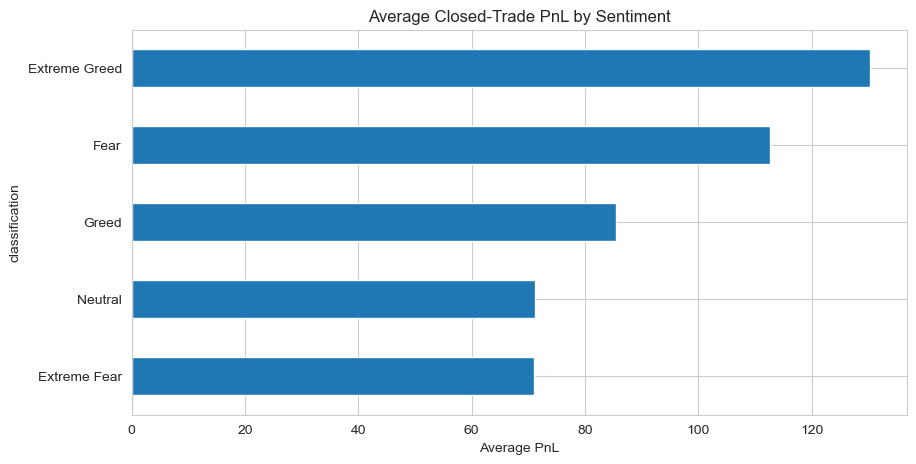

In [32]:
trade_sentiment_summary["avg_pnl_per_closed_trade"].sort_values().plot(kind="barh")
plt.title("Average Closed-Trade PnL by Sentiment")
plt.xlabel("Average PnL")
plt.show()

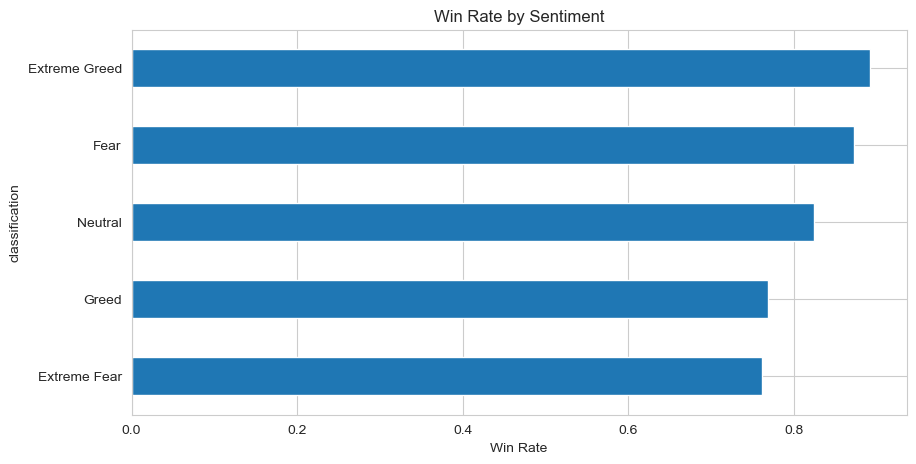

In [33]:
trade_sentiment_summary["win_rate"].sort_values().plot(kind="barh")
plt.title("Win Rate by Sentiment")
plt.xlabel("Win Rate")
plt.show()

Performance is not monotonic across sentiment regimes. Extreme Greed appears to support the highest average realized PnL per closed trade, which is consistent with stronger trend persistence. Fear days also show strong realized PnL, but this comes alongside much larger position sizes, suggesting that profitability may partly reflect higher risk-taking rather than cleaner execution.

Q2. Do traders change behavior based on sentiment?

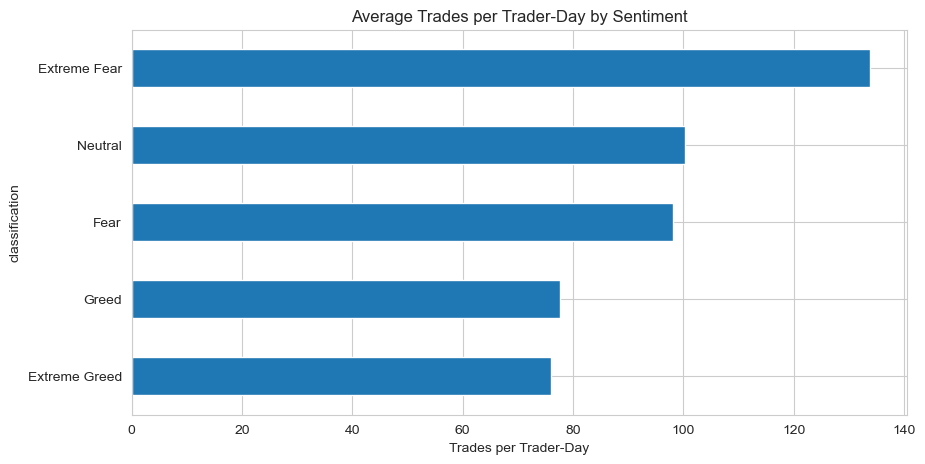

In [34]:
daily_sentiment_summary["avg_trades_per_day"].sort_values().plot(kind="barh")
plt.title("Average Trades per Trader-Day by Sentiment")
plt.xlabel("Trades per Trader-Day")
plt.show()

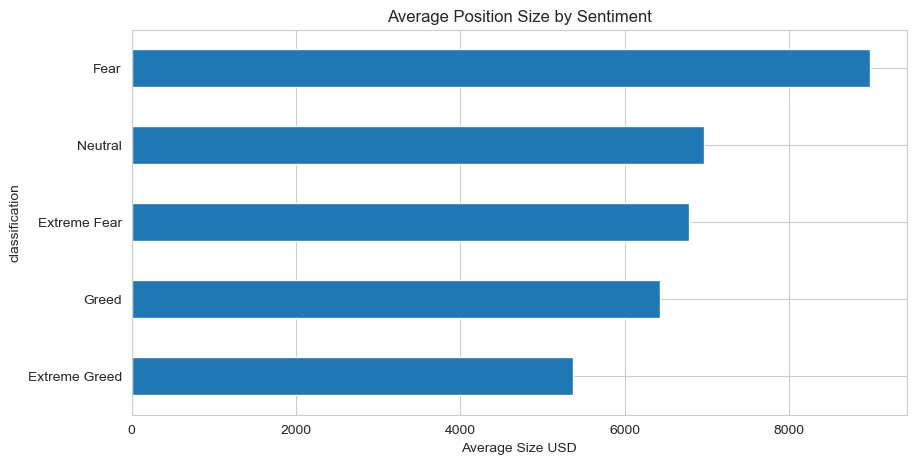

In [35]:
daily_sentiment_summary["avg_position_size_usd"].sort_values().plot(kind="barh")
plt.title("Average Position Size by Sentiment")
plt.xlabel("Average Size USD")
plt.show()

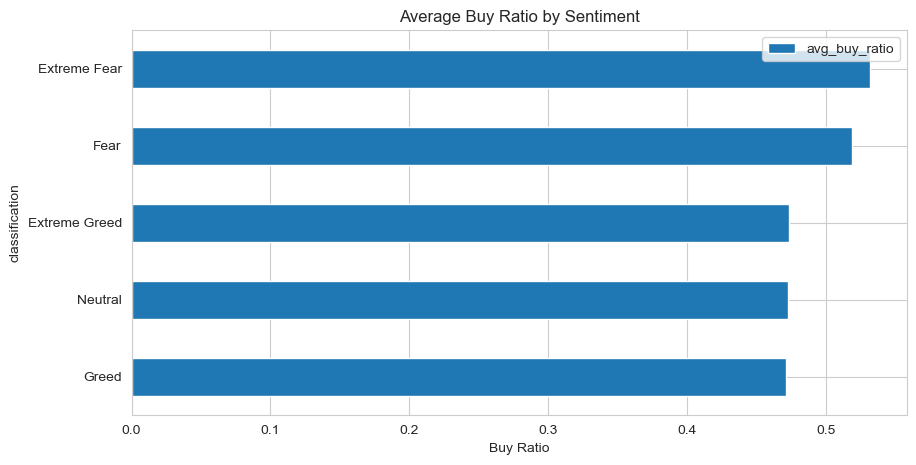

In [36]:
daily_sentiment_summary[["avg_buy_ratio"]].sort_values("avg_buy_ratio").plot(kind="barh")
plt.title("Average Buy Ratio by Sentiment")
plt.xlabel("Buy Ratio")
plt.show()

insight 1

Extreme Greed produced the highest average realized PnL per closed trade.
In the trade-level summary, Extreme Greed had the strongest average closed-trade profitability relative to the other sentiment regimes.
This suggests that momentum-following conditions may be more favorable in strong bullish sentiment, where directional continuation is easier to capture.

insight 2

Fear days were associated with larger average position sizes.
The average Size USD was highest on Fear days, exceeding the levels seen in Greed and Extreme Greed.
This implies traders may become more aggressive during fearful conditions, possibly attempting dip-buying or mean-reversion entries. That behavior can increase both upside and downside risk.

insight 3

Behavior and performance do not move together uniformly.
Although Fear days showed strong realized PnL, they also showed larger average position sizes, meaning improved PnL may partly come from higher exposure rather than better trade quality.
Therefore, strategy recommendations should separate “high-return” regimes from “high-risk” regimes instead of assuming the best PnL regime is automatically the safest.



data suggests:

Fear days have larger average trade sizes

Fear days also have high activity

Greed / Extreme Greed are associated with better average trade profitability

buy/sell balance changes, but directional behavior should be interpreted carefully because Direction contains multiple event types, not just directional entries

Direction-related fields in this dataset mix opening, closing, conversion, and liquidation-style events. Therefore, long/short indicators should be interpreted as directional exposure proxies rather than pure directional intent.

Segmentation

Frequent vs infrequent traders

In [44]:
account_summary = data.groupby("Account").agg(
    total_trades=("Account", "size"),
    active_days=("date", "nunique"),
    total_pnl=("Closed PnL", "sum"),
    avg_trade_size=("abs_size_usd", "mean"),
    closed_trades=("is_closed_trade", "sum"),
    closed_win_rate=("Closed PnL", lambda x: (x[x != 0] > 0).mean() if (x != 0).any() else np.nan)
).reset_index()

trade_median = account_summary["total_trades"].median()
account_summary["freq_segment"] = np.where(
    account_summary["total_trades"] >= trade_median,
    "Frequent",
    "Infrequent"
)

I used the sample median to define frequent versus infrequent traders because it creates balanced groups without assuming any external threshold.

Large-size vs small-size traders

In [45]:
size_median = account_summary["avg_trade_size"].median()
account_summary["size_segment"] = np.where(
    account_summary["avg_trade_size"] >= size_median,
    "Large-size",
    "Small-size"
)

Since leverage is unavailable, average trade size is used as the primary exposure segmentation variable.

Consistent winners vs others

In [46]:
winrate_median = account_summary["closed_win_rate"].median()

account_summary["winner_segment"] = np.where(
    (account_summary["total_pnl"] > 0) & (account_summary["closed_win_rate"] >= winrate_median),
    "Consistent winner",
    "Others"
)

Total PnL alone can be dominated by one or two large outcomes.
Combining positive total PnL with at-least-median closed-trade win rate gives a more stable definition of consistency.

Segment comparison table

In [47]:
segmented = data.merge(
    account_summary[["Account", "freq_segment", "size_segment", "winner_segment"]],
    on="Account",
    how="left"
)

Frequent vs infrequent by sentiment

In [48]:
freq_sentiment = segmented.groupby(["freq_segment", "classification"]).agg(
    trades=("Account", "size"),
    avg_trade_pnl=("Closed PnL", "mean"),
    avg_size_usd=("abs_size_usd", "mean"),
    closed_win_rate=("Closed PnL", lambda x: (x[x != 0] > 0).mean() if (x != 0).any() else np.nan)
).reset_index()

freq_sentiment

,freq_segment,classification,trades,avg_trade_pnl,avg_size_usd,closed_win_rate
0,Frequent,Extreme Fear,16894,34.163353,5591.430973,0.800939
1,Frequent,Extreme Greed,35020,62.870911,3115.792937,0.890511
2,Frequent,Fear,55621,51.323784,8162.301977,0.877995
3,Frequent,Greed,45485,25.004641,5819.243161,0.754121
4,Frequent,Neutral,33937,34.579701,4780.761654,0.821855
5,Infrequent,Extreme Fear,4506,35.941979,4443.547845,0.641046
6,Infrequent,Extreme Greed,4972,103.264685,3087.308111,0.902475
7,Infrequent,Fear,6216,80.835791,4718.370584,0.825320
8,Infrequent,Greed,4818,210.210287,4959.364790,0.929379
9,Infrequent,Neutral,3749,31.845656,4800.574775,0.844242


Part C — Actionable output

Strategy rules of thumb

The prompt wants actionable output. Make each recommendation tied to evidence.

Rule 1

During Fear days, reduce notional exposure unless the trader already has a strong positive win-rate profile.
Rationale: Fear days in the sample were associated with larger average position sizes, which indicates higher aggression. Since this can amplify losses as well as gains, exposure control is more important in fearful regimes.

Rule 2

During Extreme Greed, favor momentum-style participation over oversized contrarian trades.
Rationale: Extreme Greed delivered the strongest average closed-trade PnL, suggesting trend continuation may dominate. Traders may benefit more from disciplined trend participation than from large reversal bets.

Rule 3

Frequent traders should be monitored for overtrading under emotional regimes.
Rationale: if frequent traders sharply increase activity on Fear/Greed days without corresponding improvement in win rate, trade-count discipline becomes a useful risk rule.

Limitations

The dataset does not contain a direct leverage column, so leverage-specific conclusions cannot be tested.

True drawdown cannot be computed exactly because account equity curves are not provided.

Direction includes multiple event types, so long/short bias is approximate rather than exact.

Results are observational and should not be interpreted as causal.

This analysis shows that sentiment is associated with both trader behavior and realized performance on Hyperliquid, but the relationship is not purely linear. Extreme Greed appears to offer the best average realized trade profitability, while Fear is associated with more aggressive position sizing. This indicates that sentiment may be useful not only as a market-timing signal, but also as a risk-scaling input. In practice, traders may benefit from adjusting notional exposure and trade frequency based on sentiment regime rather than using the same behavior in all environments.